# KDD99 Data Analysis

This notebook explores the KDD Cup 1999 dataset before preprocessing.
The goal is to understand the available features, target labels, class balance,
and the basic structure of the data.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_kddcup99

RANDOM_STATE = 42

In [5]:
kdd = fetch_kddcup99(
    percent10=True,
    as_frame=True,
    shuffle=True,
    random_state=RANDOM_STATE,
)

df = kdd.frame.copy()

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(
            lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x
        )

print("Shape:", df.shape)
df.head()

Shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,smurf.
1,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,smurf.
2,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,smurf.
3,0,tcp,http,SF,345,5419,0,0,0,0,...,255,1.00,0.00,0.01,0.02,0.0,0.0,0.0,0.0,normal.
4,0,tcp,private,S0,0,0,0,0,0,0,...,2,0.01,0.07,0.00,0.00,1.0,1.0,0.0,0.0,neptune.


In [6]:
print("Columns:")
print(df.columns.tolist())
print("\nNumber of columns:", len(df.columns))

Columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'labels']

Number of columns: 42


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  str    
 2   service                      494021 non-null  str    
 3   flag                         494021 non-null  str    
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13  root_shell

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,494021.0,47.979302,707.746472,0.0,0.00,0.0,0.00,58329.0
src_bytes,494021.0,3025.610296,988218.101050,0.0,45.00,520.0,1032.00,693375640.0
dst_bytes,494021.0,868.532425,33040.001252,0.0,0.00,0.0,0.00,5155468.0
land,494021.0,0.000045,0.006673,0.0,0.00,0.0,0.00,1.0
wrong_fragment,494021.0,0.006433,0.134805,0.0,0.00,0.0,0.00,3.0
urgent,494021.0,0.000014,0.005510,0.0,0.00,0.0,0.00,3.0
hot,494021.0,0.034519,0.782103,0.0,0.00,0.0,0.00,30.0
num_failed_logins,494021.0,0.000152,0.015520,0.0,0.00,0.0,0.00,5.0
logged_in,494021.0,0.148247,0.355345,0.0,0.00,0.0,0.00,1.0
num_compromised,494021.0,0.010212,1.798326,0.0,0.00,0.0,0.00,884.0


In [9]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [10]:
label_counts = df["labels"].value_counts()
print(label_counts.head(20))
print("\nNumber of unique labels:", df["labels"].nunique())

labels
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
Name: count, dtype: int64

Number of unique labels: 23


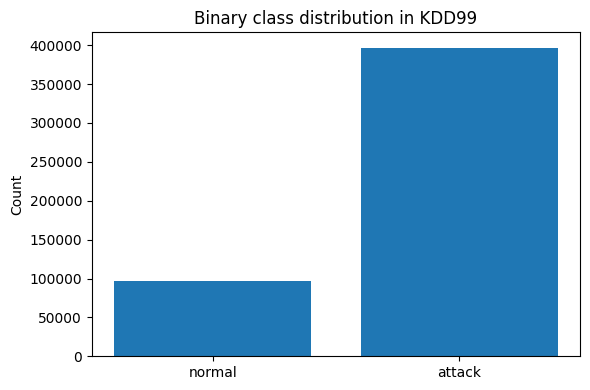

In [11]:
df["binary_label"] = (df["labels"] != "normal.").astype(int)
df["binary_label"].value_counts()

counts = df["binary_label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["normal", "attack"], counts.values)
plt.ylabel("Count")
plt.title("Binary class distribution in KDD99")
plt.tight_layout()
plt.show()

In [12]:
categorical_cols = ["protocol_type", "service", "flag"]
numerical_cols = [c for c in df.columns if c not in categorical_cols + ["labels", "binary_label"]]

print("Categorical columns:", categorical_cols)
print("Number of numerical columns:", len(numerical_cols))
print("First numerical columns:", numerical_cols[:10])

Categorical columns: ['protocol_type', 'service', 'flag']
Number of numerical columns: 38
First numerical columns: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised']


In [13]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().head(10))


=== protocol_type ===
protocol_type
icmp    283602
tcp     190065
udp      20354
Name: count, dtype: int64

=== service ===
service
ecr_i       281400
private     110893
http         64293
smtp          9723
other         7237
domain_u      5863
ftp_data      4721
eco_i         1642
ftp            798
finger         670
Name: count, dtype: int64

=== flag ===
flag
SF        378440
S0         87007
REJ        26875
RSTR         903
RSTO         579
SH           107
S1            57
S2            24
RSTOS0        11
S3            10
Name: count, dtype: int64


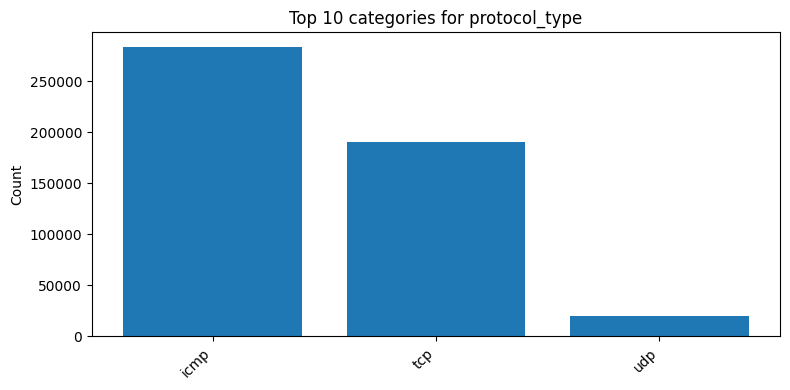

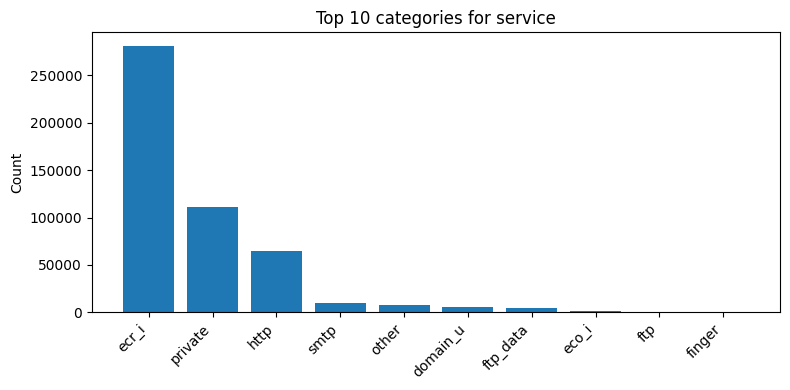

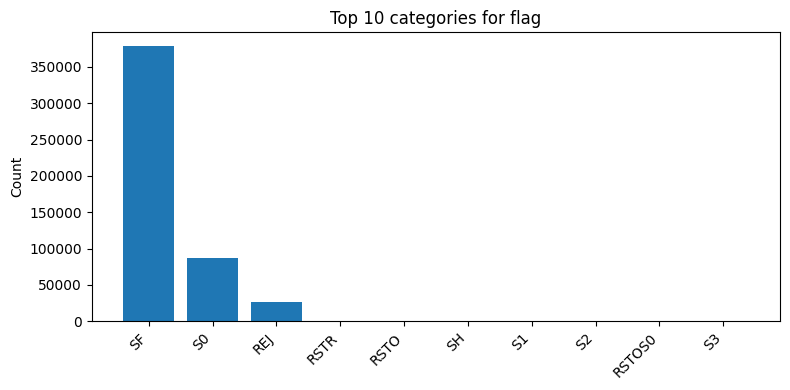

In [14]:
for col in categorical_cols:
    top_counts = df[col].value_counts().head(10)

    plt.figure(figsize=(8, 4))
    plt.bar(top_counts.index.astype(str), top_counts.values)
    plt.title(f"Top 10 categories for {col}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [15]:
selected_features = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]
df[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,494021.0,47.979302,707.746472,0.0,0.0,0.0,0.0,58329.0
src_bytes,494021.0,3025.610296,988218.101050,0.0,45.0,520.0,1032.0,693375640.0
dst_bytes,494021.0,868.532425,33040.001252,0.0,0.0,0.0,0.0,5155468.0
count,494021.0,332.285690,213.147412,0.0,117.0,510.0,511.0,511.0
srv_count,494021.0,292.906557,246.322817,0.0,10.0,510.0,511.0,511.0


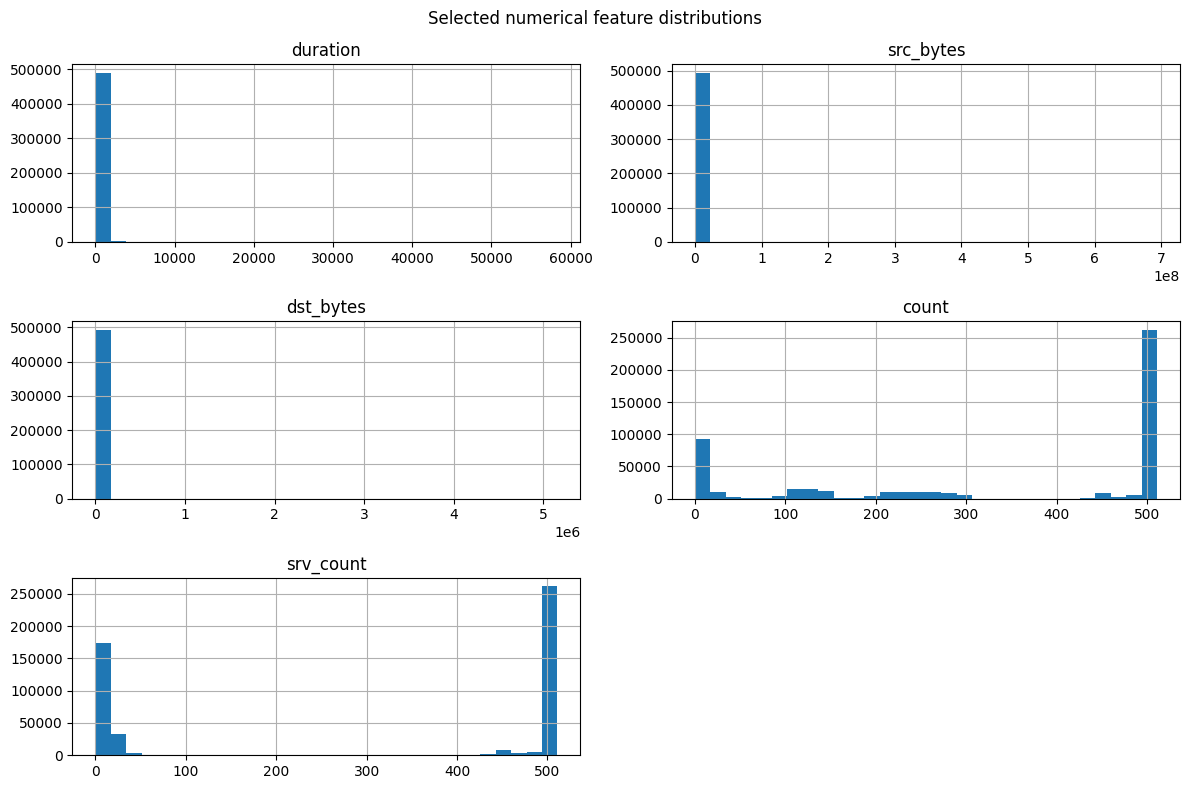

In [16]:
df[selected_features].hist(figsize=(12, 8), bins=30)
plt.suptitle("Selected numerical feature distributions")
plt.tight_layout()
plt.show()

In [17]:
sample_df = df.sample(n=5000, random_state=RANDOM_STATE).copy()

sample_df["log_src_bytes"] = np.log1p(sample_df["src_bytes"])
sample_df["log_dst_bytes"] = np.log1p(sample_df["dst_bytes"])

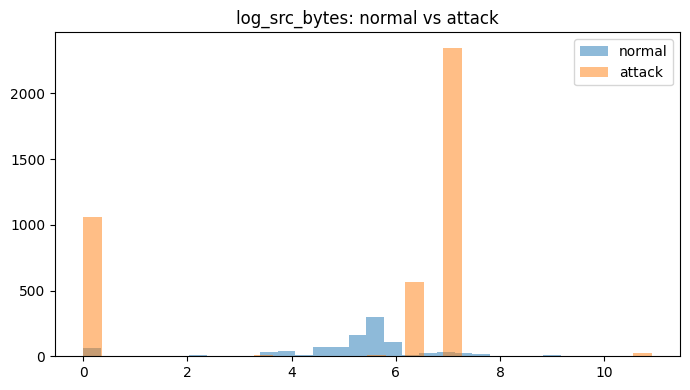

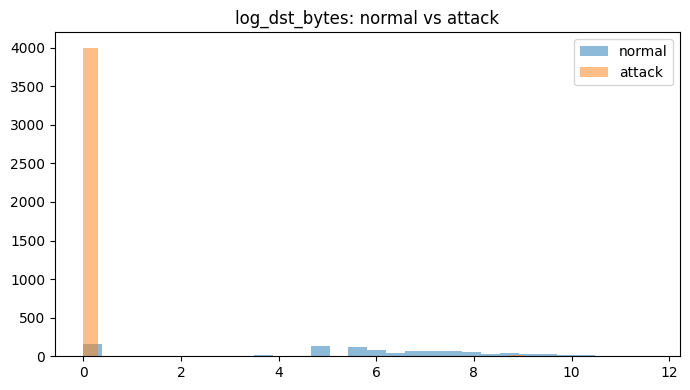

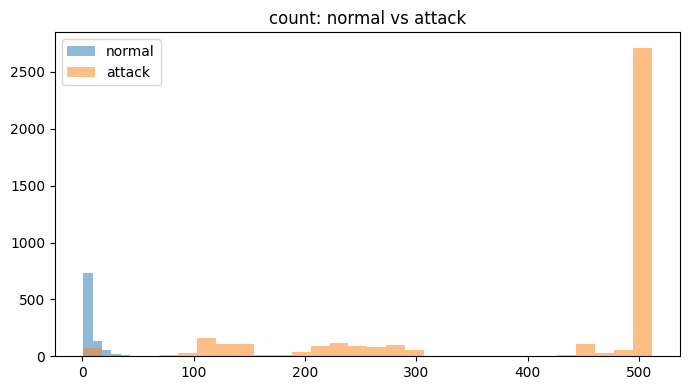

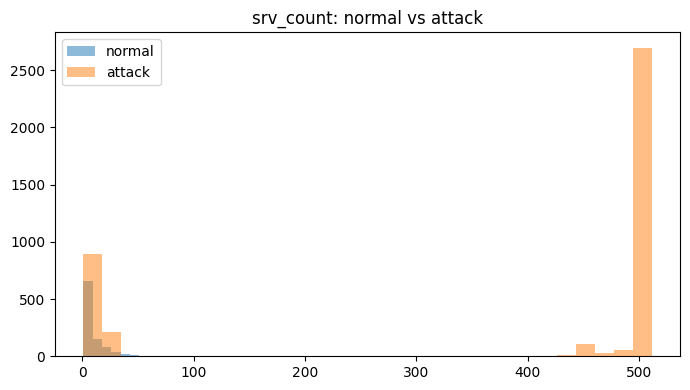

In [18]:
compare_features = ["log_src_bytes", "log_dst_bytes", "count", "srv_count"]

for feature in compare_features:
    plt.figure(figsize=(7, 4))

    normal_vals = sample_df[sample_df["binary_label"] == 0][feature]
    attack_vals = sample_df[sample_df["binary_label"] == 1][feature]

    plt.hist(normal_vals, bins=30, alpha=0.5, label="normal")
    plt.hist(attack_vals, bins=30, alpha=0.5, label="attack")
    plt.title(f"{feature}: normal vs attack")
    plt.legend()
    plt.tight_layout()
    plt.show()